In [1]:
# snmf_env

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from matplotlib import cm
import os
import pickle as pkl
import umap

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

from SigProfilerAssignment import Analyzer as Analyze

%matplotlib inline
sns.set_theme(style="whitegrid")
sns.set(rc={'figure.figsize':(10.0,8.27)})


from SigProfilerMatrixGenerator import install as genInstall
genInstall.install('GRCh37')


# LOAD Bootstrapped functions
from pathlib import Path
import sys, os, importlib

# append project root to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

import importlib
from src.processing import bootstrapping as boot
# Reload the module to ensure we have the latest version
importlib.reload(boot)

# --- Get project root dynamically ---
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent



/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tool       | Installed 
-----------------------
curl       | True      
wget       | False     
rsync      | True      


INFO - GRCh37 is already installed.


All reference files have been created.
To proceed with matrix_generation, please provide the path to your vcf files and an appropriate output path.
Installation complete.


# SNMF (Lc = 0.1 and 0.0)
for generation of randomly split fold and bootrstrapping see notebook: 0_preprocess_cellline.ipynb

In [12]:
import os
import pandas as pd
import numpy as np
import importlib
import SNMF.sigpro as sig

# ensure fresh reload
sig = importlib.reload(sig)
import importlib, SNMF.subroutines
import SNMF.nmf_cpu
importlib.reload(SNMF.subroutines)
importlib.reload(SNMF.nmf_cpu)


# --- Parameters ---
min_k = max_k = 5
reps = 10
lr = 5e-3
l_p = 0.0001
lc_values = [0.0, 0.1]
bootstrap_types = ["multinomial", "dirichlet"]

N_train, N_test = 100, 1000
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = "M" if bootstrap == "multinomial" else "D"

    for l_c in lc_values:
        l_c_str = f"{l_c:.1f}".replace(".", "")
        base_output_path = os.path.join(results_root, f"SNMF_results_{bootstrap}_lc{l_c_str}")
        os.makedirs(base_output_path, exist_ok=True)

        results_df = pd.DataFrame()

        print(f"\n=== Running SNMF ({bootstrap.upper()} bootstrap, λc={l_c}) ===")

        # 🔹 Run over all 11 splits (00–10)
        for split_id in range(11):
            split_dir = os.path.join(data_root, f"split_{split_id:02d}")
            if not os.path.exists(split_dir):
                print(f"⚠️ Skipping missing {split_dir}")
                continue

            print(f"\n--- Split {split_id:02d} ---")


            path_X_train = os.path.join(split_dir, f"Xboot{prefix}_train_all.txt")
            path_Y_train = os.path.join(split_dir, f"Yboot{prefix}_train_all.txt")
            path_X_test = os.path.join(split_dir, f"Xboot{prefix}_test.txt")
            path_Y_test = os.path.join(split_dir, f"Yboot{prefix}_test.txt")

            output_path = os.path.join(base_output_path, f"split_{split_id:02d}")
            os.makedirs(output_path, exist_ok=True)

            # --- Train SNMF ---
            print(f"→ Training SNMF on split {split_id:02d}")
            train_out = sig.sigProfilerExtractor(
                input_type="text",
                output=output_path,
                input_data=path_X_train,
                input_label=path_Y_train,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                seeds="random",
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                make_decomposition_plots=False
            )

            # --- Test SNMF ---
            print(f"→ Evaluating SNMF on split {split_id:02d}")
            test_out = sig.test_sigProfilerExtractor(
                input_type="text",
                model_path=output_path,
                output=output_path,
                test_data=path_X_test,
                test_label=path_Y_test,
                minimum_signatures=min_k,
                maximum_signatures=max_k,
                nmf_replicates=reps,
                lambda_c=l_c,
                lambda_p=l_p,
                lr=lr,
                filter=False,
                make_decomposition_plots=False
            )

            # --- Handle structured outputs ---
            if isinstance(train_out, pd.DataFrame):
                row_train = train_out.iloc[0].to_dict()
            elif isinstance(train_out, dict):
                row_train = train_out
            else:
                raise ValueError("train_out must be a dict or DataFrame")

            if isinstance(test_out, (list, tuple)):
                acc_test, f1_test, rec_test = test_out
            elif isinstance(test_out, dict):
                acc_test = test_out.get("acc_test", np.nan)
                f1_test = test_out.get("f1_test", np.nan)
                rec_test = test_out.get("rec_test", np.nan)
            elif isinstance(test_out, pd.DataFrame):
                acc_test = test_out.loc[0, "acc_test"]
                f1_test = test_out.loc[0, "f1_test"]
                rec_test = test_out.loc[0, "rec_test"]
            else:
                raise ValueError("test_out must be list/dict/DataFrame")

            # --- Aggregate results ---
            df_comb = pd.DataFrame([{
                "split": split_id,
                "bootstrap": bootstrap,
                "lambda_c": l_c,
                "accuracy_test": acc_test,
                "f1_test": f1_test,
                "recall_test": rec_test,
                "Lrec_train": row_train.get("Lrec_mean", np.nan),
                "Lce_train": row_train.get("Lce_mean", np.nan),
                "Ltot_train": row_train.get("Ltot_mean", np.nan),
                "stability": row_train.get("stability_mean_refit0", np.nan),
                "n_filter": row_train.get("n_filter", np.nan),
                "epochs_mean": row_train.get("epochs_mean", np.nan),
                "k": min_k,
                "lr": lr,
                "lambda_p": l_p,
                "reps": reps
            }])

            results_df = pd.concat([results_df, df_comb], ignore_index=True)

            print(f"✅ Split {split_id:02d}: acc={acc_test:.3f}, f1={f1_test:.3f}, rec={rec_test:.3f}")

        # --- Save per (bootstrap, λc) condition ---
        final_results_path = os.path.join(
            results_root, f"SNMF_{bootstrap}_lc{l_c_str}_full.csv"
        )
        results_df.to_csv(final_results_path, index=False)
        print(f"\n💾 Saved {bootstrap} λc={l_c} results → {final_results_path}")



=== Running SNMF (MULTINOMIAL bootstrap, λc=0.0) ===

--- Split 00 ---
→ Training SNMF on split 00

************** Reported Current Memory Use: 0.07 GB *****************

Extracting signature 5 for mutation type 96
The matrix normalizing cutoff is 9600


random
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.228
random
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.261
random
random
random
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.218
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.229
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.243
random
random
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.251
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.262
random
Epoch: 0 ; Ltot = 0.99 ;  Lrec = 0.99 ; Lce = 1.39 ; acc = 0.275
Epoch: 100 ; Ltot = 0.28 ;  Lrec = 0.28 ; Lce = 0.37 ; acc = 0.882
Epoch: 100 ; Ltot = 0.29 ;  Lrec = 0.29 ; Lce = 0.43 ; acc = 0.873
Epoch: 100 ; Ltot = 0.29 ;  Lrec =

## LR on X (96 SBS) to predict Y (pathway)

In [27]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# --- Paths ---
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)

# --- Hyperparameter space ---
param_grid = {"C": np.logspace(-2, 2, 11)}  # 0.01 → 100

# --- Bootstraps to benchmark ---
for bootstrap in ["multinomial", "dirichlet"]:
    prefix = "M" if bootstrap == "multinomial" else "D"
    output_dir = os.path.join(results_root, f"LR_96sbs_{bootstrap}")
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n=== Running LR benchmark on {bootstrap.upper()} bootstraps with 3-fold CV ===")

    all_results = []

    # --- 11 bootstrap splits ---
    for split_id in range(11):
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        if not os.path.exists(split_dir):
            print(f"⚠️ Skipping missing {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        # --- Load folds (3 folds for CV) ---
        X_folds, y_folds = [], []
        for fold_id in range(1, 4):
            Xf = pd.read_csv(os.path.join(split_dir, "sub_folds", f"fold_{fold_id}", f"Xboot{prefix}_train_fold{fold_id}.txt"), sep="\t", index_col=0).T
            yf = pd.read_csv(os.path.join(split_dir, "sub_folds", f"fold_{fold_id}", f"Yboot{prefix}_train_fold{fold_id}.txt"), sep="\t", index_col=0).T
            X_folds.append(Xf)
            y_folds.append(yf.idxmax(axis=1))

        # Concatenate folds into one big training set
        X_train_val = pd.concat(X_folds)
        y_train_val = pd.concat(y_folds)

        # --- Prepare test data ---
        X_test = pd.read_csv(os.path.join(split_dir, f"Xboot{prefix}_test.txt"), sep="\t", index_col=0).T
        y_test_df = pd.read_csv(os.path.join(split_dir, f"Yboot{prefix}_test.txt"), sep="\t", index_col=0).T
        y_test = y_test_df.idxmax(axis=1)

        # --- Custom 3-fold CV indices ---
        n_samples = len(X_train_val)
        fold_size = n_samples // 3
        idx = np.arange(n_samples)
        folds = [idx[i * fold_size:(i + 1) * fold_size] for i in range(3)]
        train_idx = [
            np.concatenate([folds[1], folds[2]]),
            np.concatenate([folds[0], folds[2]]),
            np.concatenate([folds[0], folds[1]])
        ]
        test_idx = folds
        custom_cv = list(zip(train_idx, test_idx))

        # --- Grid search ---
        base_model = LogisticRegression(
            solver="saga", 
            penalty="l2", max_iter=1000, random_state=42
        )

        grid = GridSearchCV(
            base_model,
            param_grid,
            scoring="f1_macro",
            cv=custom_cv,
            refit=True,
            return_train_score=False,
            n_jobs=-1
        )

        grid.fit(X_train_val.values, y_train_val.values)
        best_C = grid.best_params_["C"]
        print(f"Best C: {best_C:.4g} (mean CV F1 = {grid.best_score_:.3f})")

        # --- Retrain best model on all train folds ---
        best_model = LogisticRegression(
            solver="saga",
            penalty="l2", C=best_C, max_iter=1000, random_state=42
        )
        best_model.fit(X_train_val, y_train_val)

        # --- Evaluate on test set ---
        y_pred = best_model.predict(X_test)
        acc = metrics.accuracy_score(y_test, y_pred)
        f1 = metrics.f1_score(y_test, y_pred, average="macro")
        rec = metrics.recall_score(y_test, y_pred, average="macro")

        all_results.append({
            "split": split_id,
            "bootstrap": bootstrap,
            "accuracy": acc,
            "f1_score": f1,
            "recall": rec,
            "best_C": best_C
        })

        print(f"Split {split_id:02d}: F1={f1:.3f}, Acc={acc:.3f}")

    # --- Save results ---
    df_results = pd.DataFrame(all_results)
    out_csv = os.path.join(output_dir, "lr_96sbs_all_splits_CV.csv")
    df_results.to_csv(out_csv, index=False)

    summary = df_results.describe().loc[["mean", "std"]]
    summary.to_csv(os.path.join(output_dir, "summary.csv"))

    print("\nSummary:")
    print(summary)
    print(f"✅ Results saved to: {out_csv}")



=== Running LR benchmark on MULTINOMIAL bootstraps with 3-fold CV ===

--- Split 00 ---
Best C: 39.81 (mean CV F1 = 0.919)
Split 00: F1=0.973, Acc=0.973

--- Split 01 ---
Best C: 39.81 (mean CV F1 = 0.930)
Split 01: F1=0.961, Acc=0.961

--- Split 02 ---
Best C: 100 (mean CV F1 = 0.889)
Split 02: F1=0.934, Acc=0.935

--- Split 03 ---
Best C: 100 (mean CV F1 = 0.895)
Split 03: F1=0.951, Acc=0.952

--- Split 04 ---
Best C: 39.81 (mean CV F1 = 0.899)
Split 04: F1=0.983, Acc=0.983

--- Split 05 ---
Best C: 100 (mean CV F1 = 0.944)
Split 05: F1=0.911, Acc=0.910

--- Split 06 ---
Best C: 39.81 (mean CV F1 = 0.917)
Split 06: F1=0.975, Acc=0.975

--- Split 07 ---
Best C: 100 (mean CV F1 = 0.943)
Split 07: F1=0.887, Acc=0.892

--- Split 08 ---
Best C: 100 (mean CV F1 = 0.933)
Split 08: F1=0.949, Acc=0.949

--- Split 09 ---
Best C: 100 (mean CV F1 = 0.952)
Split 09: F1=0.902, Acc=0.903

--- Split 10 ---
Best C: 100 (mean CV F1 = 0.919)
Split 10: F1=0.965, Acc=0.965

Summary:
         split  accu

# COSMIC fitting 

In [32]:
# ===== COSMIC fit for sub-folds (new 11 splits) =====
from SigProfilerAssignment import Analyzer as Analyze
import os
import pandas as pd

# --- Configuration ---
# bootstrap_types = ["multinomial", "dirichlet"]
# prefix_map = {"multinomial": "M", "dirichlet": "D"}
bootstrap_types = ["dirichlet"]  # ["multinomial", "dirichlet"] if needed
prefix_map = {"dirichlet": "D"}  # extend to D if adding dirichlet
contexts = ["train_fold", "test"]  # folds for training, plus test sets

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    print(f"\n=== Running COSMIC fit for {bootstrap.upper()} bootstraps (sub-folds) ===")

    for split_id in range(11):
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        if not os.path.exists(split_dir):
            print(f"⚠️ Skipping missing split folder: {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        # --- Handle 3 sub-folds inside sub_folds directory ---
        subfold_dir = os.path.join(split_dir, "sub_folds")
        if not os.path.exists(subfold_dir):
            print(f"⚠️ No sub_folds folder in {split_dir}")
            continue

        for fold_id in range(1, 4):
            fold_path = os.path.join(subfold_dir, f"fold_{fold_id}")
            if not os.path.exists(fold_path):
                print(f"⚠️ Missing fold path: {fold_path}")
                continue

            # Each fold has its own train file
            input_train = os.path.join(fold_path, f"Xboot{prefix}_train_fold{fold_id}.txt")
            if not os.path.exists(input_train):
                print(f"⚠️ Missing train input: {input_train}")
                continue

            try:
                # --- Scale counts for SigProfiler ---
                df_train = pd.read_csv(input_train, sep="\t", index_col=0)
                df_scaled = df_train * 1000
                scaled_path = input_train.replace(".txt", "_1000x.txt")
                df_scaled.to_csv(scaled_path, sep="\t", index_label="MutationType")

                # --- Output directory for this fold ---
                output_dir = os.path.join(split_dir, f"cosmic_fit_{bootstrap}", f"fold_{fold_id}")
                os.makedirs(output_dir, exist_ok=True)

                print(f"→ Fitting COSMIC signatures: {bootstrap} / split {split_id:02d} / fold {fold_id}")
                Analyze.cosmic_fit(
                    samples=scaled_path,
                    output=output_dir,
                    input_type="matrix",
                    context_type="96",
                    verbose=False
                )
                print("   ✓ Done")

            except Exception as e:
                print(f"❌ Error processing {bootstrap} / split {split_id:02d} / fold {fold_id}: {e}")

print("\n✅ Finished COSMIC fitting for all sub-folds and test sets.")



=== Running COSMIC fit for DIRICHLET bootstraps (sub-folds) ===

--- Split 00 ---
→ Fitting COSMIC signatures: dirichlet / split 00 / fold 1
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures: dirichlet / split 00 / fold 2
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures: dirichlet / split 00 / fold 3
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done

--- Split 01 ---
→ Fitting COSMIC signatures: dirichlet / split 01 / fold 1
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures: dirichlet / split 01 / fold 2
Assigning COSMIC

In [ ]:
# ===== LR - E_cosmic (new 11 splits) =====
from SigProfilerAssignment import Analyzer as Analyze
import os
import pandas as pd

# --- Configuration ---
# bootstrap_types = ["multinomial", "dirichlet"]
bootstrap_types = ["multinomial"]
# prefix_map = {"multinomial": "M", "dirichlet": "D"}
prefix_map = {"multinomial": "M"}
contexts = ["train_all", "test"]

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)

# --- Main loop ---
for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    print(f"\n=== Running COSMIC fit for {bootstrap.upper()} bootstraps ===")

    for split_id in range(11):  # now includes split_10
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        if not os.path.exists(split_dir):
            print(f"⚠️ Skipping missing split folder: {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        for context in contexts:
            # Each split has train/test versions: XbootM_train.txt, XbootM_test.txt, etc.
            input_file = os.path.join(split_dir, f"Xboot{prefix}_{context}.txt")
            if not os.path.exists(input_file):
                print(f"⚠️ Missing input file: {input_file}")
                continue

            try:
                # Scale counts (SigProfilerAssignment expects integer-like counts)
                df = pd.read_csv(input_file, sep="\t", index_col=0)
                df_scaled = df * 1000
                scaled_path = input_file.replace(".txt", "_1000x.txt")
                df_scaled.to_csv(scaled_path, sep="\t", index_label="MutationType")

                # Output directory for this split/context
                output_dir = os.path.join(split_dir, f"cosmic_fit_{bootstrap}", context)
                os.makedirs(output_dir, exist_ok=True)

                print(f"→ Fitting COSMIC signatures for {bootstrap} / split {split_id:02d} / {context}")
                Analyze.cosmic_fit(
                    samples=scaled_path,
                    output=output_dir,
                    input_type="matrix",
                    context_type="96",
                    verbose=False
                )
                print("   ✓ Done")

            except Exception as e:
                print(f"❌ Error processing {bootstrap} / split {split_id:02d} / {context}: {e}")

print("\n✅ Finished COSMIC fitting for all bootstraps and all 11 splits.")



=== Running COSMIC fit for MULTINOMIAL bootstraps ===

--- Split 00 ---
→ Fitting COSMIC signatures for multinomial / split 00 / train_all
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures for multinomial / split 00 / test
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done

--- Split 01 ---
→ Fitting COSMIC signatures for multinomial / split 01 / train_all
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done
→ Fitting COSMIC signatures for multinomial / split 01 / test
Assigning COSMIC sigs or Signature Database ...... 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
   ✓ Done

--- Split 02 ---
→ Fitting COSMIC signatures for multinomial /

: 

In [34]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# ============================================================
# CONFIGURATION
# ============================================================
bootstrap_types = ["multinomial", "dirichlet"]
prefix_map = {"multinomial": "M", "dirichlet": "D"}
# bootstrap_types = ["multinomial"]  # ["multinomial", "dirichlet"] if needed
# prefix_map = {"multinomial": "M"}  # extend to D if adding dirichlet
param_grid = {"C": np.logspace(-2, 2, 11)}  # search 0.01 → 100

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_root = os.path.join(project_root, "data", "processed", "zou2021", "splits_new")
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
os.makedirs(results_root, exist_ok=True)


## ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_cosmic_exposures(split_dir, bootstrap, fold_or_context):
    """Load COSMIC exposures from SigProfilerAssignment output."""
    fit_dir = os.path.join(split_dir, f"cosmic_fit_{bootstrap}", fold_or_context, "Assignment_Solution", "Activities")
    fit_path = os.path.join(fit_dir, "Assignment_Solution_Activities.txt")
    if not os.path.exists(fit_path):
        raise FileNotFoundError(f"Missing exposures: {fit_path}")
    df = pd.read_csv(fit_path, sep="\t", index_col=0)
    if df.shape[0] < df.shape[1]:  # ensure samples as rows
        df = df.T
    return df


# ============================================================
# MAIN LOOP
# ============================================================

for bootstrap in bootstrap_types:
    prefix = prefix_map[bootstrap]
    print(f"\n=== Logistic Regression (E-COSMIC CV) on {bootstrap.upper()} bootstraps ===")

    results = []

    for split_id in range(11):
        split_dir = os.path.join(data_root, f"split_{split_id:02d}")
        subfold_dir = os.path.join(split_dir, "sub_folds")
        if not os.path.exists(split_dir):
            print(f"⚠️ Missing split folder: {split_dir}")
            continue

        print(f"\n--- Split {split_id:02d} ---")

        # 1️⃣ Load fold exposures and Y from correct locations
        X_folds, y_folds = [], []
        for fold_id in range(1, 4):
            try:
                # exposures: split_##/cosmic_fit_bootstrap/fold_i/...
                Xf = load_cosmic_exposures(split_dir, bootstrap, f"fold_{fold_id}")
                # labels: split_##/sub_folds/fold_i/YbootM_train_foldi.txt
                Y_path = os.path.join(subfold_dir, f"fold_{fold_id}", f"Yboot{prefix}_train_fold{fold_id}.txt")
                Yf = pd.read_csv(Y_path, sep="\t", index_col=0).T
                yf = Yf.idxmax(axis=1)

                common = Xf.index.intersection(yf.index)
                X_folds.append(Xf.loc[common])
                y_folds.append(yf.loc[common])
            except FileNotFoundError as e:
                print(f"⚠️ {e}")
                continue

        if len(X_folds) < 3:
            print("⚠️ Not all fold exposures/labels found, skipping split.")
            continue

        X_train_val = pd.concat(X_folds)
        y_train_val = pd.concat(y_folds)

        # 2️⃣ Load test exposures and labels
        try:
            X_test = load_cosmic_exposures(split_dir, bootstrap, "test")
            Yt_path = os.path.join(split_dir, f"Yboot{prefix}_test.txt")
            Yt = pd.read_csv(Yt_path, sep="\t", index_col=0).T
            y_test = Yt.idxmax(axis=1)
            common_test = X_test.index.intersection(y_test.index)
            X_test = X_test.loc[common_test]
            y_test = y_test.loc[common_test]
        except FileNotFoundError as e:
            print(f"⚠️ {e}")
            continue

        # 3️⃣ Define custom CV (3 folds)
        n = len(X_train_val)
        fold_size = n // 3
        idx = np.arange(n)
        folds = [idx[i * fold_size:(i + 1) * fold_size] for i in range(3)]
        train_idx = [
            np.concatenate([folds[1], folds[2]]),
            np.concatenate([folds[0], folds[2]]),
            np.concatenate([folds[0], folds[1]])
        ]
        test_idx = folds
        custom_cv = list(zip(train_idx, test_idx))

        # 4️⃣ GridSearchCV for C
        base_model = LogisticRegression(
            solver="saga",
            penalty="l2", max_iter=4000, random_state=42
        )
        grid = GridSearchCV(
            base_model, param_grid,
            scoring="f1_macro", cv=custom_cv,
            refit=True, n_jobs=-1
        )
        grid.fit(X_train_val.values, y_train_val.values)
        best_C = grid.best_params_["C"]
        print(f"Best C = {best_C:.3f}, mean CV F1 = {grid.best_score_:.3f}")

        # 5️⃣ Retrain best model and evaluate
        best_model = LogisticRegression(
            solver="saga", 
            penalty="l2", C=best_C, max_iter=4000, random_state=42
        )
        best_model.fit(X_train_val, y_train_val)
        y_pred = best_model.predict(X_test)

        acc = metrics.accuracy_score(y_test, y_pred)
        f1 = metrics.f1_score(y_test, y_pred, average="macro")
        rec = metrics.recall_score(y_test, y_pred, average="macro")

        results.append({
            "split": split_id,
            "bootstrap": bootstrap,
            "accuracy": acc,
            "f1_score": f1,
            "recall": rec,
            "best_C": best_C
        })

        print(f"Split {split_id:02d}: Acc={acc:.3f}, F1={f1:.3f}, Recall={rec:.3f}")

    # 6️⃣ Save results
    df_results = pd.DataFrame(results)
    out_csv = os.path.join(results_root, f"LR_EcosmicCV_{bootstrap}.csv")
    df_results.to_csv(out_csv, index=False)
    print(f"\n✅ Saved results → {out_csv}")
    print(df_results.describe())



=== Logistic Regression (E-COSMIC CV) on MULTINOMIAL bootstraps ===

--- Split 00 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.398, mean CV F1 = 0.920
Split 00: Acc=0.965, F1=0.964, Recall=0.964

--- Split 01 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.025, mean CV F1 = 0.942
Split 01: Acc=0.908, F1=0.906, Recall=0.908

--- Split 02 ---
Best C = 0.010, mean CV F1 = 0.928
Split 02: Acc=0.944, F1=0.944, Recall=0.944

--- Split 03 ---
Best C = 0.063, mean CV F1 = 0.900
Split 03: Acc=0.953, F1=0.952, Recall=0.953

--- Split 04 ---
Best C = 0.158, mean CV F1 = 0.939
Split 04: Acc=0.886, F1=0.881, Recall=0.886

--- Split 05 ---
Best C = 0.158, mean CV F1 = 0.921
Split 05: Acc=0.976, F1=0.976, Recall=0.976

--- Split 06 ---
Best C = 0.398, mean CV F1 = 0.952
Split 06: Acc=0.907, F1=0.904, Recall=0.907

--- Split 07 ---


...

Best C = 1.000, mean CV F1 = 0.932
Split 07: Acc=0.934, F1=0.934, Recall=0.935

--- Split 08 ---
Best C = 0.010, mean CV F1 = 0.900
Split 08: Acc=0.995, F1=0.995, Recall=0.995

--- Split 09 ---
Best C = 0.010, mean CV F1 = 0.907
Split 09: Acc=0.973, F1=0.973, Recall=0.973

--- Split 10 ---
Best C = 0.010, mean CV F1 = 0.921
Split 10: Acc=0.976, F1=0.976, Recall=0.976

✅ Saved results → /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_EcosmicCV_multinomial.csv
           split   accuracy   f1_score     recall     best_C
count  11.000000  11.000000  11.000000  11.000000  11.000000
mean    5.000000   0.947000   0.946044   0.947000   0.203764
std     3.316625   0.034661   0.036165   0.034661   0.302574
min     0.000000   0.886250   0.881058   0.886250   0.010000
25%     2.500000   0.921250   0.920084   0.921250   0.010000
50%     5.000000   0.952500   0.952422   0.952500   0.063096
75%     7.500000   0.974750   0.974721   0.974750   0.278298
max    10.000000   0.994

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.158, mean CV F1 = 0.861
Split 00: Acc=0.873, F1=0.872, Recall=0.873

--- Split 01 ---
Best C = 0.063, mean CV F1 = 0.874
Split 01: Acc=0.849, F1=0.849, Recall=0.849

--- Split 02 ---
Best C = 0.010, mean CV F1 = 0.855
Split 02: Acc=0.867, F1=0.867, Recall=0.866

--- Split 03 ---
Best C = 0.010, mean CV F1 = 0.843
Split 03: Acc=0.874, F1=0.873, Recall=0.874

--- Split 04 ---
Best C = 0.025, mean CV F1 = 0.881
Split 04: Acc=0.854, F1=0.853, Recall=0.854

--- Split 05 ---
Best C = 0.010, mean CV F1 = 0.875
Split 05: Acc=0.878, F1=0.878, Recall=0.878

--- Split 06 ---


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warni

Best C = 0.010, mean CV F1 = 0.861
Split 06: Acc=0.861, F1=0.860, Recall=0.861

--- Split 07 ---
Best C = 0.010, mean CV F1 = 0.859
Split 07: Acc=0.891, F1=0.890, Recall=0.891

--- Split 08 ---
Best C = 0.158, mean CV F1 = 0.858
Split 08: Acc=0.892, F1=0.891, Recall=0.892

--- Split 09 ---
Best C = 0.010, mean CV F1 = 0.865
Split 09: Acc=0.896, F1=0.896, Recall=0.896

--- Split 10 ---
Best C = 0.010, mean CV F1 = 0.854
Split 10: Acc=0.979, F1=0.979, Recall=0.979

✅ Saved results → /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_EcosmicCV_dirichlet.csv
           split   accuracy   f1_score     recall     best_C
count  11.000000  11.000000  11.000000  11.000000  11.000000
mean    5.000000   0.883023   0.882595   0.883023   0.043199
std     3.316625   0.035479   0.035540   0.035479   0.059179
min     0.000000   0.849000   0.849328   0.849000   0.010000
25%     2.500000   0.863750   0.863290   0.863750   0.010000
50%     5.000000   0.873750   0.872952   0.873750  

# Plot results

✅ Loaded SNMF results: multinomial, λc=0.0 (11 rows)
✅ Loaded SNMF results: multinomial, λc=0.1 (11 rows)
✅ Loaded SNMF results: dirichlet, λc=0.0 (11 rows)
✅ Loaded SNMF results: dirichlet, λc=0.1 (11 rows)
✅ Loaded LR (96 SBS) from: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_96sbs_multinomial/lr_96sbs_all_splits_CV.csv
✅ Loaded LR (96 SBS) from: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_96sbs_dirichlet/lr_96sbs_all_splits_CV.csv
✅ Loaded LR (COSMIC exposures) from: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_EcosmicCV_multinomial.csv
✅ Loaded LR (COSMIC exposures) from: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new3/LR_EcosmicCV_dirichlet.csv

🔹 Wilcoxon signed-rank summary (Integrated SNMF vs others):
MULTINOMIAL → Integrated SNMF > Non-integrated SNMF: p=0.000977 (***)
MULTINOMIAL → Integrated SNMF > LR (original 96 SBS): p=0.183 (ns)
MULTINOMIAL → Integrated SNMF > LR (

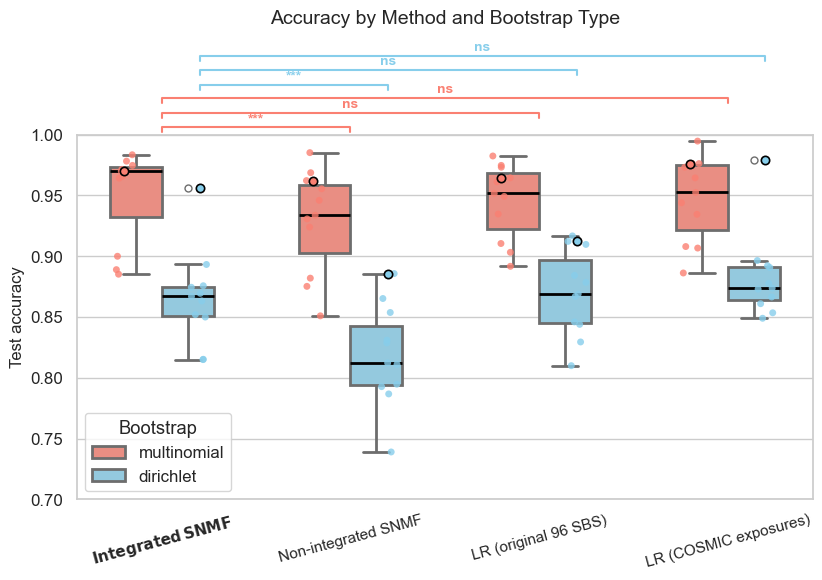


Summary (median, mean ± std):
          method_full   bootstrap  median  mean   std  count
      Integrated SNMF   dirichlet   0.867 0.867 0.038     11
  Non-integrated SNMF   dirichlet   0.812 0.818 0.041     11
 LR (original 96 SBS)   dirichlet   0.869 0.870 0.035     11
LR (COSMIC exposures)   dirichlet   0.874 0.883 0.035     11
      Integrated SNMF multinomial   0.970 0.950 0.038     11
  Non-integrated SNMF multinomial   0.934 0.929 0.043     11
 LR (original 96 SBS) multinomial   0.952 0.945 0.031     11
LR (COSMIC exposures) multinomial   0.952 0.947 0.035     11


In [38]:
# ===== Combined SNMF + LR (96SBS + COSMIC exposures) results =====
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

sns.set(style="whitegrid", font_scale=1.1)
%matplotlib inline

# ---------------------------------------------------------------------
# 1. Define project directories
# ---------------------------------------------------------------------
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
results_root = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new3")
fig_dir = os.path.join(project_root, "results", "figures", "sup", "bootstrapping")
os.makedirs(fig_dir, exist_ok=True)

# ---------------------------------------------------------------------
# 2. Load SNMF results (λc = 0 and 0.1, both bootstraps)
# ---------------------------------------------------------------------
snmf_files = [
    ("multinomial", 0.0, os.path.join(results_root, "SNMF_multinomial_lc00_full.csv")),
    ("multinomial", 0.1, os.path.join(results_root, "SNMF_multinomial_lc01_full.csv")),
    ("dirichlet", 0.0, os.path.join(results_root, "SNMF_dirichlet_lc00_full.csv")),
    ("dirichlet", 0.1, os.path.join(results_root, "SNMF_dirichlet_lc01_full.csv")),
]

df_snmf_all = []
for bootstrap, lc, fpath in snmf_files:
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df["bootstrap"] = bootstrap
        df["lambda_c"] = lc
        df["method"] = f"SNMF lc{lc:g}"
        df_snmf_all.append(df)
        print(f"✅ Loaded SNMF results: {bootstrap}, λc={lc} ({len(df)} rows)")
    else:
        print(f"⚠️ Missing: {fpath}")

df_snmf = pd.concat(df_snmf_all, ignore_index=True)
df_snmf = df_snmf.rename(columns={
    "accuracy_test": "acc_test",
    "f1_test": "f1",
    "recall_test": "rec"
})

# ---------------------------------------------------------------------
# 3. Load LR (96 SBS) results
# ---------------------------------------------------------------------
df_lr_all = []
for bootstrap in ["multinomial", "dirichlet"]:
    lr_dir = os.path.join(results_root, f"LR_96sbs_{bootstrap}")
    lr_file = os.path.join(lr_dir, "lr_96sbs_all_splits_CV.csv")
    if os.path.exists(lr_file):
        df_lr = pd.read_csv(lr_file)
        df_lr["method"] = "LR X SBS"
        df_lr["bootstrap"] = bootstrap
        df_lr.rename(columns={"accuracy": "acc_test"}, inplace=True)
        df_lr_all.append(df_lr)
        print(f"✅ Loaded LR (96 SBS) from: {lr_file}")
df_lr_all = pd.concat(df_lr_all, ignore_index=True) if df_lr_all else pd.DataFrame()

# ---------------------------------------------------------------------
# 4. Load LR (COSMIC exposures) results
# ---------------------------------------------------------------------
df_lr_cosmic_all = []
for bootstrap in ["multinomial", "dirichlet"]:
    lr_cosmic_file = os.path.join(results_root, f"LR_EcosmicCV_{bootstrap}.csv")
    if os.path.exists(lr_cosmic_file):
        df_lr_cosmic = pd.read_csv(lr_cosmic_file)
        df_lr_cosmic["method"] = "LR E COSMIC"
        df_lr_cosmic["bootstrap"] = bootstrap
        df_lr_cosmic.rename(columns={"accuracy": "acc_test"}, inplace=True)
        df_lr_cosmic_all.append(df_lr_cosmic)
        print(f"✅ Loaded LR (COSMIC exposures) from: {lr_cosmic_file}")
df_lr_cosmic_all = pd.concat(df_lr_cosmic_all, ignore_index=True) if df_lr_cosmic_all else pd.DataFrame()

# ---------------------------------------------------------------------
# 5. Combine all methods
# ---------------------------------------------------------------------
df_all = pd.concat([df_snmf, df_lr_all, df_lr_cosmic_all], ignore_index=True, sort=False)

method_mapping = {
    "SNMF lc0.1": "Integrated SNMF",
    "SNMF lc0": "Non-integrated SNMF",
    "LR X SBS": "LR (original 96 SBS)",
    "LR E COSMIC": "LR (COSMIC exposures)",
}
order = ["Integrated SNMF", "Non-integrated SNMF", "LR (original 96 SBS)", "LR (COSMIC exposures)"]
df_all["method_full"] = df_all["method"].map(method_mapping)
df_all["method_full"] = pd.Categorical(df_all["method_full"], categories=order, ordered=True)

# ---------------------------------------------------------------------
# 6. Wilcoxon signed-rank tests
# ---------------------------------------------------------------------
def wilcoxon_vs_integrated(df, bootstrap):
    results = {}
    integrated = df.loc[(df["method_full"] == "Integrated SNMF") & (df["bootstrap"] == bootstrap)]
    for m in [m for m in order if m != "Integrated SNMF"]:
        other = df.loc[(df["method_full"] == m) & (df["bootstrap"] == bootstrap)]

        if "split" in integrated.columns and "split" in other.columns:
            common = np.intersect1d(integrated["split"], other["split"])
            x = integrated.loc[integrated["split"].isin(common), "acc_test"].values
            y = other.loc[other["split"].isin(common), "acc_test"].values
        else:
            x, y = integrated["acc_test"].values, other["acc_test"].values

        if len(x) > 1 and len(y) > 1:
            try:
                stat, p = wilcoxon(x, y, alternative="greater", zero_method="wilcox")
            except ValueError:
                p = np.nan
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            results[m] = (p, sig)
    return results


stats_results = {b: wilcoxon_vs_integrated(df_all, b) for b in ["multinomial", "dirichlet"]}

print("\n🔹 Wilcoxon signed-rank summary (Integrated SNMF vs others):")
for b, res in stats_results.items():
    for m, (p, sig) in res.items():
        print(f"{b.upper()} → Integrated SNMF > {m}: p={p:.3g} ({sig})")

# ---------------------------------------------------------------------
# 7. Plot accuracy distributions + highlight split 10
# ---------------------------------------------------------------------
palette = {"multinomial": "salmon", "dirichlet": "skyblue"}
fig, ax = plt.subplots(figsize=(8.5, 6))

sns.boxplot(
    data=df_all, x="method_full", y="acc_test", hue="bootstrap",
    palette=palette, width=0.55, showfliers=True,
    boxprops=dict(linewidth=2), whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2), medianprops=dict(linewidth=2, color="black"),
    flierprops=dict(marker="o", markersize=5, linestyle="none"), ax=ax
)
sns.stripplot(
    data=df_all, x="method_full", y="acc_test", hue="bootstrap",
    dodge=True, size=5, alpha=0.8, palette=palette, ax=ax
)

# --- Overlay: highlight split 10 ---
df_split10 = df_all[df_all["split"] == 10]
if not df_split10.empty:
    sns.stripplot(
        data=df_split10, x="method_full", y="acc_test", hue="bootstrap",
        dodge=True, size=6, alpha=1.0, palette=palette,
        edgecolor="black", linewidth=1.2, ax=ax, legend=False
    )
    print(f"✅ Highlighted {len(df_split10)} split 10 samples")

# --- Legend + labels ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Bootstrap")

ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0.7, 1.0)
ax.set_xticklabels(
    [r"$\bf{" + label.replace(' ', '\,') + "}$" if label == "Integrated SNMF" else label
     for label in order],
    fontsize=11
)
ax.set_title("Accuracy by Method and Bootstrap Type", fontsize=14, pad=80)

# --- Significance bars ---
ymax = 0.99
offset = 0.012
for b_i, b in enumerate(["multinomial", "dirichlet"]):
    for j, m in enumerate(order[1:], start=1):
        if m in stats_results[b]:
            p, sig = stats_results[b][m]
            x1 = 0 + b_i * 0.2
            x2 = j + b_i * 0.2
            y = ymax + (b_i * 0.035) + (j * offset)
            ax.plot([x1, x1, x2, x2],
                    [y, y + offset / 3, y + offset / 3, y],
                    lw=1.5, c=palette[b], clip_on=False)
            ax.text((x1 + x2) / 2, y + offset / 2, sig,
                    ha='center', va='bottom',
                    color=palette[b], fontsize=10, fontweight='bold',
                    clip_on=False)

plt.xticks(rotation=15)
plt.tight_layout()

# ---------------------------------------------------------------------
# 8. Save figure
# ---------------------------------------------------------------------
fig_path = os.path.join(fig_dir, "accuracy_by_method_bootstrap_with_cosmic.pdf")
plt.savefig(fig_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"\n✅ Saved figure to: {fig_path}")
plt.show()

# ---------------------------------------------------------------------
# 9. Summary table
# ---------------------------------------------------------------------
summary = (
    df_all.groupby(["method_full", "bootstrap"])["acc_test"]
    .agg(["median", "mean", "std", "count"])
    .reset_index()
    .sort_values(["bootstrap", "method_full"])
)

# Round all numeric values to 3 decimals
summary[["median", "mean", "std"]] = summary[["median", "mean", "std"]].round(3)

print("\nSummary (median, mean ± std):")
print(summary.to_string(index=False))


In [39]:
df_all

,split,bootstrap,lambda_c,acc_test,f1,rec,Lrec_train,Lce_train,Ltot_train,stability,...,epochs_mean,k,lr,lambda_p,reps,method,f1_score,recall,best_C,method_full
0,0,multinomial,0.0,0.93075,0.931191,4.489919,0.265143,0.183146,0.265143,1.0,...,21000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
1,1,multinomial,0.0,0.98525,0.985249,4.214739,0.264134,0.118442,0.264134,1.0,...,15000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
2,2,multinomial,0.0,0.92400,0.924734,4.524746,0.261939,0.188743,0.261939,1.0,...,15000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
3,3,multinomial,0.0,0.93375,0.933337,4.068469,0.272800,0.234068,0.272800,1.0,...,21000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
4,4,multinomial,0.0,0.96875,0.968523,4.288735,0.272282,0.154910,0.272282,1.0,...,15000.0,5.0,0.005,0.0001,10.0,SNMF lc0,NaN,NaN,NaN,Non-integrated SNMF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,6,dirichlet,NaN,0.86100,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.859672,0.86100,0.010000,LR (COSMIC exposures)
84,7,dirichlet,NaN,0.89075,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.889964,0.89075,0.010000,LR (COSMIC exposures)
85,8,dirichlet,NaN,0.89225,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.891290,0.89225,0.158489,LR (COSMIC exposures)
86,9,dirichlet,NaN,0.89650,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,LR E COSMIC,0.896114,0.89650,0.010000,LR (COSMIC exposures)


✅ Filtered to multinomial only: 44 rows

✅ Saved multinomial-only figure to: /Users/sande/Projects/SNMF/results/figures/sup/bootstrapping/accuracy_by_method_multinomial.pdf


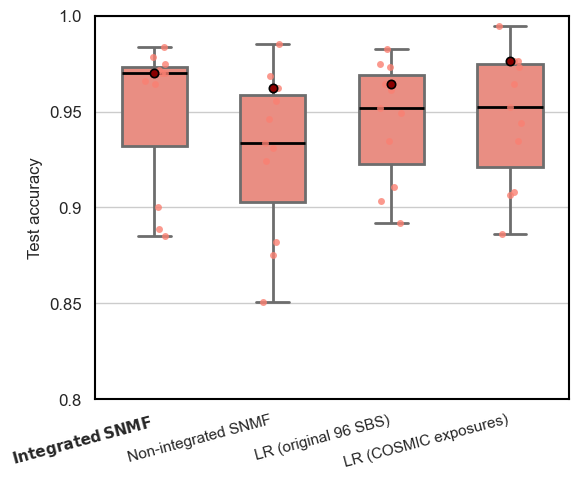

In [41]:
# ---------------------------------------------------------------------
# 8. Plot accuracy distributions (MULTINOMIAL ONLY)
# ---------------------------------------------------------------------

# ✅ Filter to multinomial only
df_plot = df_all[df_all["bootstrap"] == "multinomial"].copy()
print(f"✅ Filtered to multinomial only: {len(df_plot)} rows")

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=df_plot, x="method_full", y="acc_test",
    color="salmon", width=0.55, showfliers=True,
    boxprops=dict(linewidth=2), whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2), medianprops=dict(linewidth=2, color="black"),
    flierprops=dict(marker="o", markersize=5, linestyle="none"), ax=ax
)
sns.stripplot(
    data=df_plot, x="method_full", y="acc_test",
    color="salmon", size=5, alpha=0.8, ax=ax
)

# --- Highlight split 10 ---
df_split10 = df_plot[df_plot["split"] == 10]
if not df_split10.empty:
    sns.stripplot(
        data=df_split10, x="method_full", y="acc_test",
        color="darkred", size=6, alpha=1.0,
        edgecolor="black", linewidth=1.2, ax=ax, legend=False
    )

# --- Labels / ticks ---
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0.8, 1.0)
ax.set_yticks([0.8, 0.85, 0.9, 0.95, 1.0])
ax.set_yticklabels(["0.8", "0.85", "0.9", "0.95", "1.0"])

ax.set_xticklabels(
    [r"$\bf{" + label.replace(' ', '\,') + "}$" if label == "Integrated SNMF" else label
     for label in order],
    fontsize=11, rotation=15
)

# --- Nudge x-tick labels slightly left ---
for lbl in ax.get_xticklabels():
    lbl.set_horizontalalignment("right")
    lbl.set_x(lbl.get_position()[0] - 10.55)

# --- Black frame around the plot ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor("black")

# --- Significance bars ---
ymax = 0.99
offset = 0.012
for j, m in enumerate(order[1:], start=1):
    if m in stats_results:
        p, sig = stats_results[m]
        x1, x2 = 0, j
        y = ymax + (j * offset)
        ax.plot([x1, x1, x2, x2],
                [y, y + offset / 3, y + offset / 3, y],
                lw=1.5, c="salmon", clip_on=False)
        ax.text((x1 + x2) / 2, y + offset / 2, sig,
                ha='center', va='bottom',
                color="salmon", fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()

fig_path = os.path.join(fig_dir, "accuracy_by_method_multinomial.pdf")
# plt.savefig(fig_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"\n✅ Saved multinomial-only figure to: {fig_path}")
plt.show()


✅ Filtered to multinomial-only SNMF data: 22 rows

--- STABILITY ---
Integrated SNMF > Non-integrated SNMF: p=1 (ns)

Summary (stability, multinomial only, median, mean ± std):
          method_full  median  mean   std  count
      Integrated SNMF     1.0 0.967 0.047     11
  Non-integrated SNMF     1.0 1.000 0.000     11
 LR (original 96 SBS)     NaN   NaN   NaN      0
LR (COSMIC exposures)     NaN   NaN   NaN      0


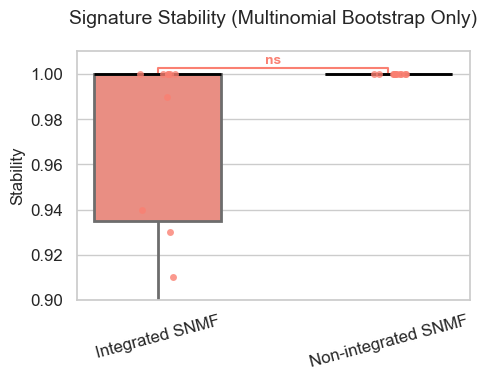

✅ Saved stability figure to: /Users/sande/Projects/SNMF/results/figures/sup/bootstrapping/stability_snmf_multinomial.pdf

--- REC ---
Integrated SNMF > Non-integrated SNMF: p=0.000488 (***)

Summary (rec, multinomial only, median, mean ± std):
          method_full  median  mean   std  count
      Integrated SNMF   4.604 4.627 0.317     11
  Non-integrated SNMF   4.399 4.417 0.300     11
 LR (original 96 SBS)     NaN   NaN   NaN      0
LR (COSMIC exposures)     NaN   NaN   NaN      0


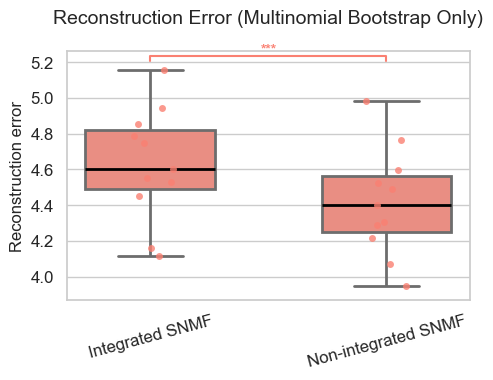

✅ Saved rec figure to: /Users/sande/Projects/SNMF/results/figures/sup/bootstrapping/rec_snmf_multinomial.pdf


In [44]:
# ---------------------------------------------------------------------
# 10. Stability and Reconstruction Error (SNMF only, MULTINOMIAL ONLY)
# ---------------------------------------------------------------------

# ✅ Filter to SNMF methods and multinomial bootstraps only
df_snmf = df_all[
    (df_all["method_full"].isin(["Integrated SNMF", "Non-integrated SNMF"])) &
    (df_all["bootstrap"] == "multinomial")
].copy()

print(f"✅ Filtered to multinomial-only SNMF data: {len(df_snmf)} rows")

metrics = ["stability", "rec"]
titles = {"stability": "Signature Stability", "rec": "Reconstruction Error"}
ylabels = {"stability": "Stability", "rec": "Reconstruction error"}

for metric in metrics:
    print(f"\n--- {metric.upper()} ---")
    
    # --- Wilcoxon signed-rank test (Integrated > Non-integrated) ---
    df_i = df_snmf[df_snmf["method_full"] == "Integrated SNMF"]
    df_n = df_snmf[df_snmf["method_full"] == "Non-integrated SNMF"]
    common_splits = np.intersect1d(df_i["split"], df_n["split"])
    x = df_i.loc[df_i["split"].isin(common_splits), metric].values
    y = df_n.loc[df_n["split"].isin(common_splits), metric].values
    
    if len(x) > 1 and len(y) > 1:
        try:
            stat, p = wilcoxon(x, y, alternative="greater", zero_method="wilcox")
        except ValueError:
            p = np.nan
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"Integrated SNMF > Non-integrated SNMF: p={p:.3g} ({sig})")
    else:
        p, sig = np.nan, "n/a"
        print(f"Wilcoxon test skipped: insufficient data.")
    
    # --- Summary statistics ---
    summary_metric = (
        df_snmf.groupby(["method_full"])[metric]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values("method_full")
    )
    summary_metric[["median", "mean", "std"]] = summary_metric[["median", "mean", "std"]].round(3)
    print(f"\nSummary ({metric}, multinomial only, median, mean ± std):")
    print(summary_metric.to_string(index=False))

    # --- Boxplot ---
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.boxplot(
        data=df_snmf, x="method_full", y=metric,
        color="salmon", width=0.55, showfliers=True,
        boxprops=dict(linewidth=2), whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2), medianprops=dict(linewidth=2, color="black"),
        flierprops=dict(marker="o", markersize=5, linestyle="none"), ax=ax
    )
    sns.stripplot(
        data=df_snmf, x="method_full", y=metric,
        color="salmon", size=5, alpha=0.8, ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(ylabels[metric], fontsize=12)
    ax.set_title(f"{titles[metric]} (Multinomial Bootstrap Only)", fontsize=14, pad=20)
    
    # --- Adaptive y-limits ---
    if metric == "stability":
        ax.set_ylim(0.9, 1.01)
        ymin, ymax = 0.9, 1.01
    elif metric == "rec":
        ymin, ymax = df_snmf[metric].min(), df_snmf[metric].max()
        ax.set_ylim(ymin * 0.98, ymax * 1.02)

    # --- Significance annotation ---
    x1, x2 = 0, 1
    y = df_snmf[metric].max() * (1.01 if metric == "rec" else 1.0005)
    offset = (ymax - ymin) * 0.02 if metric == "rec" else 0.002
    ax.plot([x1, x1, x2, x2], [y, y + offset, y + offset, y],
            lw=1.5, c="salmon", clip_on=False)
    ax.text((x1 + x2) / 2, y + offset * 1.3, sig, ha='center', va='bottom',
            color="salmon", fontsize=10, fontweight='bold', clip_on=False)
    
    plt.xticks(rotation=15)
    plt.tight_layout()
    out_path = os.path.join(fig_dir, f"{metric}_snmf_multinomial.pdf")
    plt.savefig(out_path, format="pdf", bbox_inches="tight", dpi=300)
    plt.show()
    print(f"✅ Saved {metric} figure to: {out_path}")


# SNMF Cell-line - Analysis

Loaded exposures from:
/Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new/SNMF_results_multinomial_lc01/split_10/SBS96/Suggested_Solution/SBS96_De-Novo_Solution/Activities/SBS96_De-Novo_Activities.txt
Saved annotated exposures to:
/Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new/SNMF_results_multinomial_lc01/split_10/SBS96/Suggested_Solution/SBS96_De-Novo_Solution/Activities/Avg_Signature_Exposure_Annotated.txt
Saved heatmap to:
/Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new/SNMF_results_multinomial_lc01/split_10/SBS96/Suggested_Solution/SBS96_De-Novo_Solution/Activities/Avg_Signature_Exposure_Annotated_Heatmap.pdf


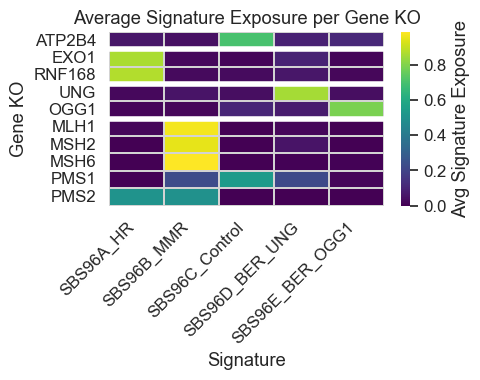

In [63]:

# --- Define Pathways ---
pathway_genes = {
    "Control": ["ATP2B4"],
    "HR": ["EXO1", "RNF168"],
    "BER": ["UNG", "OGG1"],
    "MMR": ["MLH1", "MSH2", "MSH6", "PMS1", "PMS2"]
}

# --- Load exposures ---
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
# Corrected path to split_10, not run_10
model_path = os.path.join(
    project_root,
    "results", "analysis", "bootstrap_comparison_new",
    "SNMF_results_multinomial_lc01",
    "split_10"
)

exposures_path = os.path.join(
    model_path,
    "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution",
    "Activities", "SBS96_De-Novo_Activities.txt"
)

# --- Read exposures ---
exposures = pd.read_csv(exposures_path, sep="\t", index_col=0)
print(f"Loaded exposures from:\n{exposures_path}")

# --- Extract gene KO from sample names ---
exposures['gene_KO'] = exposures.index.str.split('_').str[0]

# --- Compute average exposures per gene KO ---
avg_exposure_per_gene = exposures.groupby('gene_KO').mean()

# --- Drop accidental 'gene_KO' column if present ---
avg_exposure_per_gene = avg_exposure_per_gene.drop(columns=['gene_KO'], errors='ignore')

# --- Determine dominant pathway per signature ---
# --- Transpose to signatures as rows ---
signature_exposures = avg_exposure_per_gene.T  # rows: signatures, columns: genes

# --- Determine dominant pathway per signature ---
gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathway_genes.items()
    for gene in genes
}
# --- Transpose to signatures as rows ---
signature_exposures = avg_exposure_per_gene.T  # rows: signatures, columns: genes

# --- Determine dominant pathway per signature ---
gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathway_genes.items()
    for gene in genes
}

# Build a DataFrame of average exposures grouped by pathway
pathway_exposures = {
    pathway: signature_exposures[[g for g in genes if g in signature_exposures.columns]].mean(axis=1)
    for pathway, genes in pathway_genes.items()
}

pathway_df = pd.DataFrame(pathway_exposures)  # shape: (signatures, pathways)

# For each signature, get dominant pathway
dominant_pathway = pathway_df.idxmax(axis=1)

# Count how many signatures per pathway
pathway_counts = dominant_pathway.value_counts()

# For each signature, get top gene within dominant pathway
top_gene_in_pathway = []
for sig in signature_exposures.index:
    pathway = dominant_pathway.get(sig, "Unknown")
    genes = pathway_genes.get(pathway, [])
    available_genes = [g for g in genes if g in signature_exposures.columns]
    if available_genes:
        top_gene = signature_exposures.loc[sig, available_genes].idxmax()
    else:
        top_gene = "Unknown"
    top_gene_in_pathway.append(top_gene)

# --- Conditionally rename signature columns ---
renamed_columns = []
for sig, pathway, top_gene in zip(signature_exposures.index, dominant_pathway, top_gene_in_pathway):
    if pathway_counts[pathway] > 1:
        # More than one signature with this pathway — append gene
        renamed_columns.append(f"{sig}_{pathway}_{top_gene}")
    else:
        # Only one signature with this pathway — just append pathway
        renamed_columns.append(f"{sig}_{pathway}")

# --- Apply to avg_exposure_per_gene ---
avg_exposure_per_gene.columns = renamed_columns

# --- Reorder genes by pathway ---
ordered_genes = [gene for genes in pathway_genes.values() for gene in genes]
avg_exposure_per_gene = avg_exposure_per_gene.loc[ordered_genes]

# --- Save annotated exposures ---
annotated_output_path = os.path.join(model_path, "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution", "Activities", "Avg_Signature_Exposure_Annotated.txt")
avg_exposure_per_gene.to_csv(annotated_output_path, sep="\t")
print(f"Saved annotated exposures to:\n{annotated_output_path}")

# --- Plot heatmap ---
plt.figure(figsize=(5, 4))
ax = sns.heatmap(avg_exposure_per_gene, cmap="viridis", linewidths=0.3,
                 linecolor='lightgray', annot=False, cbar_kws={'label': 'Avg Signature Exposure'})
plt.title("Average Signature Exposure per Gene KO")
plt.xlabel("Signature")
plt.ylabel("Gene KO")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# --- Add black lines to separate pathways ---
separators = np.cumsum([len(v) for v in pathway_genes.values()])[:-1]
for sep in separators:
    ax.axhline(sep, color='white', linewidth=4)

plt.tight_layout()

# --- Save the heatmap plot to Activities folder ---
heatmap_path = os.path.join(
    model_path,
    "SBS96",
    "Suggested_Solution",
    "SBS96_De-Novo_Solution",
    "Activities",
    "Avg_Signature_Exposure_Annotated_Heatmap.pdf"
)
plt.savefig(heatmap_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved heatmap to:\n{heatmap_path}")

plt.show()


In [58]:
# # --- Load classifier weights ---
# W = pd.read_csv(weights_path, sep="\t", index_col=0)
# print(f"✅ Loaded classifier weights from: {weights_path}")

W

,0,1,2,3,4,5
0,NaN,0.000000,1.000000,2.000000,3.000000,4.000000
1,0.0,2.165716,-5.094008,6.101450,-0.093130,2.998174
2,1.0,-1.090145,20.179571,0.550060,-2.394703,-9.719137
3,2.0,10.458972,-3.516768,-4.577615,-3.364912,-2.055843
4,3.0,-11.425971,-11.453426,-1.992202,5.937475,8.852547


✅ Loaded Ytest from: /Users/sande/Projects/SNMF/data/processed/bootstrapped_multinomial/N_1000/YbootM_test.text
✅ Loaded annotated exposures from: /Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new/SNMF_results_multinomial_lc01/split_10/SBS96/Suggested_Solution/SBS96_De-Novo_Solution/Activities/Avg_Signature_Exposure_Annotated.txt
✅ W matrix with labeled rows and columns:
         SBS96A_HR  SBS96B_MMR  SBS96C_Control  SBS96D_BER_UNG  \
Control   2.165716   -5.094008        6.101450       -0.093130   
MMR      -1.090145   20.179571        0.550060       -2.394703   
HR       10.458972   -3.516768       -4.577615       -3.364912   
BER     -11.425971  -11.453426       -1.992202        5.937475   

         SBS96E_BER_OGG1  
Control         2.998174  
MMR            -9.719137  
HR             -2.055843  
BER             8.852547  
✅ Saved annotated W matrix to:
/Users/sande/Projects/SNMF/results/analysis/bootstrap_comparison_new/SNMF_results_multinomial_lc01/split_10/SB

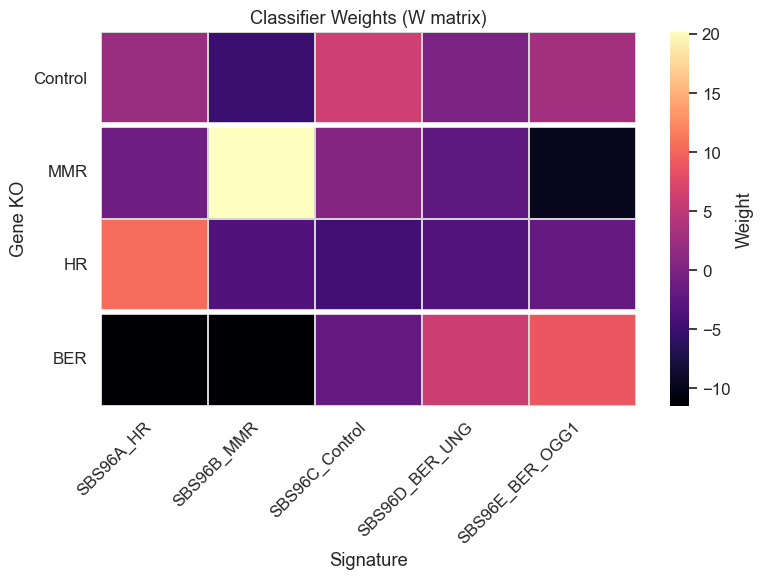

In [64]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Setup ---
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
bootstrap = "multinomial"   # or "dirichlet"
prefix = "M" if bootstrap == "multinomial" else "D"

# ✅ Fixed: correct model path to split_10
model_path = os.path.join(
    project_root,
    "results", "analysis", "bootstrap_comparison_new",
    f"SNMF_results_{bootstrap}_lc01",
    "split_10"
)

# --- Paths ---
N_test = 1000
data_path = os.path.join(project_root, "data", "processed", f"bootstrapped_{bootstrap}")
path_Y_test = os.path.join(data_path, f"N_{N_test}", f"Yboot{prefix}_test.text")

weights_path = os.path.join(
    model_path, "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution",
    "Signatures", "SBS96_De-Novo_weights.txt"
)
annotated_exposures_path = os.path.join(
    model_path, "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution",
    "Activities", "Avg_Signature_Exposure_Annotated.txt"
)

# --- Load true class labels (Ytest) ---
Ytest = pd.read_csv(path_Y_test, sep="\t", index_col=0)
print(f"✅ Loaded Ytest from: {path_Y_test}")

# --- Load annotated average exposures (to get new signature names) ---
avg_exposure_per_gene = pd.read_csv(annotated_exposures_path, sep="\t", index_col=0)
signature_labels = avg_exposure_per_gene.columns.tolist()
print(f"✅ Loaded annotated exposures from: {annotated_exposures_path}")

# --- Load W without treating first col as index ---
# W = pd.read_csv(weights_path, sep="\t", header=None)
W = pd.read_csv(weights_path, sep="\t", index_col=0)

# --- Assign signature labels from annotated exposures ---
signature_labels = avg_exposure_per_gene.columns.tolist()
if len(W.columns) != len(signature_labels):
    raise ValueError(
        f"Mismatch: W has {len(W.columns)} cols, annotated exposures have {len(signature_labels)}"
    )
W.columns = signature_labels

# --- Assign pathway or gene labels as rows ---
# Assuming order: [Control, MMR, HR, BER]
# If you know exact order, replace below accordingly
W.index = ["Control", "MMR", "HR", "BER"]

print("✅ W matrix with labeled rows and columns:")
print(W.head())


# --- Align W to Ytest order ---
missing_genes = set(Ytest.index) - set(W.index)
if missing_genes:
    print(f"⚠️ Warning: Some genes/classes in Ytest missing from W: {missing_genes}")
    print(Ytest)

common_genes = [gene for gene in Ytest.index if gene in W.index]
W = W.loc[common_genes]

# --- Save annotated W matrix ---
W_annotated_path = os.path.join(
    model_path, "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution",
    "Activities", "W_matrix_annotated.txt"
)
W.to_csv(W_annotated_path, sep="\t")
print(f"✅ Saved annotated W matrix to:\n{W_annotated_path}")

# --- Plot heatmap of the weight matrix ---
plt.figure(figsize=(8, 6))
ax = sns.heatmap(W, cmap="magma", linewidths=0.3, linecolor='lightgray',
                 cbar_kws={'label': 'Weight'}, annot=False)
plt.title("Classifier Weights (W matrix)")
plt.xlabel("Signature")
plt.ylabel("Gene KO")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# --- Add horizontal separators by pathway ---
pathway_genes = {
    "Control": ["ATP2B4"],
    "HR": ["EXO1", "RNF168"],
    "BER": ["UNG", "OGG1"],
    "MMR": ["MLH1", "MSH2", "MSH6", "PMS1", "PMS2"]
}
ordered_genes = [gene for genes in pathway_genes.values() for gene in genes]
separators = np.cumsum([len(pathway_genes[p]) for p in pathway_genes])[:-1]
for sep in separators:
    ax.axhline(sep, color='white', linewidth=4)

plt.tight_layout()

# --- Save heatmap ---
W_heatmap_path = os.path.join(
    model_path, "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution",
    "Activities", "W_matrix_annotated_Heatmap.pdf"
)
plt.savefig(W_heatmap_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ Saved W matrix heatmap to:\n{W_heatmap_path}")

plt.show()


In [71]:
snmf_exposures = pd.read_csv(exposures_path, sep="\t", index_col=0)
snmf_exposures.index = ['-'.join(s.split('-')[:3]) for s in snmf_exposures.index]
snmf_exposures.columns = renamed_columns

snmf_exposures

,SBS96A_HR,SBS96B_MMR,SBS96C_Control,SBS96D_BER_UNG,SBS96E_BER_OGG1
EXO1_real_test,0.768523,0.014773,0.000000,0.193294,0.023411
RNF168_real_test,0.716723,0.000000,0.099859,0.146162,0.037256
RNF168_real_test.1,0.756027,0.000000,0.040732,0.203241,0.000000
EXO1_real_test.1,0.843786,0.062527,0.000000,0.032447,0.061240
RNF168_real_test.2,0.755970,0.000000,0.009774,0.197741,0.036515
...,...,...,...,...,...
MLH1_real_test.208,0.002292,0.930883,0.000000,0.066825,0.000000
MSH2_real_test.208,0.000000,0.967882,0.000000,0.019859,0.012259
MSH6_real_test.193,0.000000,1.000000,0.000000,0.000000,0.000000
PMS1_real_test.183,0.071631,0.185281,0.377718,0.365370,0.000000


In [78]:
exposure_dir = os.path.join(project_root, "data", "processed","zou2021","splits_new", "split_10", f"cosmic_fit_{bootstrap}")
cosmic_path = os.path.join(exposure_dir, "test", "Assignment_Solution", "Activities", "Assignment_Solution_Activities.txt")
cosmic_exposures = pd.read_csv(cosmic_path, sep="\t", index_col=0)
# cosmic_exposures.index = ['-'.join(s.split('-')[:3]) for s in cosmic_exposures.index]
cosmic_exposures

,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,SBS7d,...,SBS90,SBS91,SBS92,SBS93,SBS94,SBS95,SBS96,SBS97,SBS98,SBS99
Samples,,,,,,,,,,,,,,,,,,,,,
EXO1_real_test,0,0,0,0,341,0,0,0,0,0,...,0,0,0,211,0,0,0,0,0,0
RNF168_real_test,0,0,0,0,346,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
RNF168_real_test.1,0,0,0,0,517,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EXO1_real_test.1,0,0,0,0,533,0,0,0,0,0,...,0,0,0,163,0,0,0,0,0,0
RNF168_real_test.2,0,0,0,0,492,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MLH1_real_test.208,48,0,0,0,257,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MSH2_real_test.208,47,0,0,0,178,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MSH6_real_test.193,24,0,0,0,233,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
common_idx = cosmic_exposures.index.intersection(snmf_exposures.index)

Saved supplementary figure to /Users/sande/Projects/SNMF/results/figures/sup/tcga/snmf_vs_cosmic_similarity_heatmap.pdf


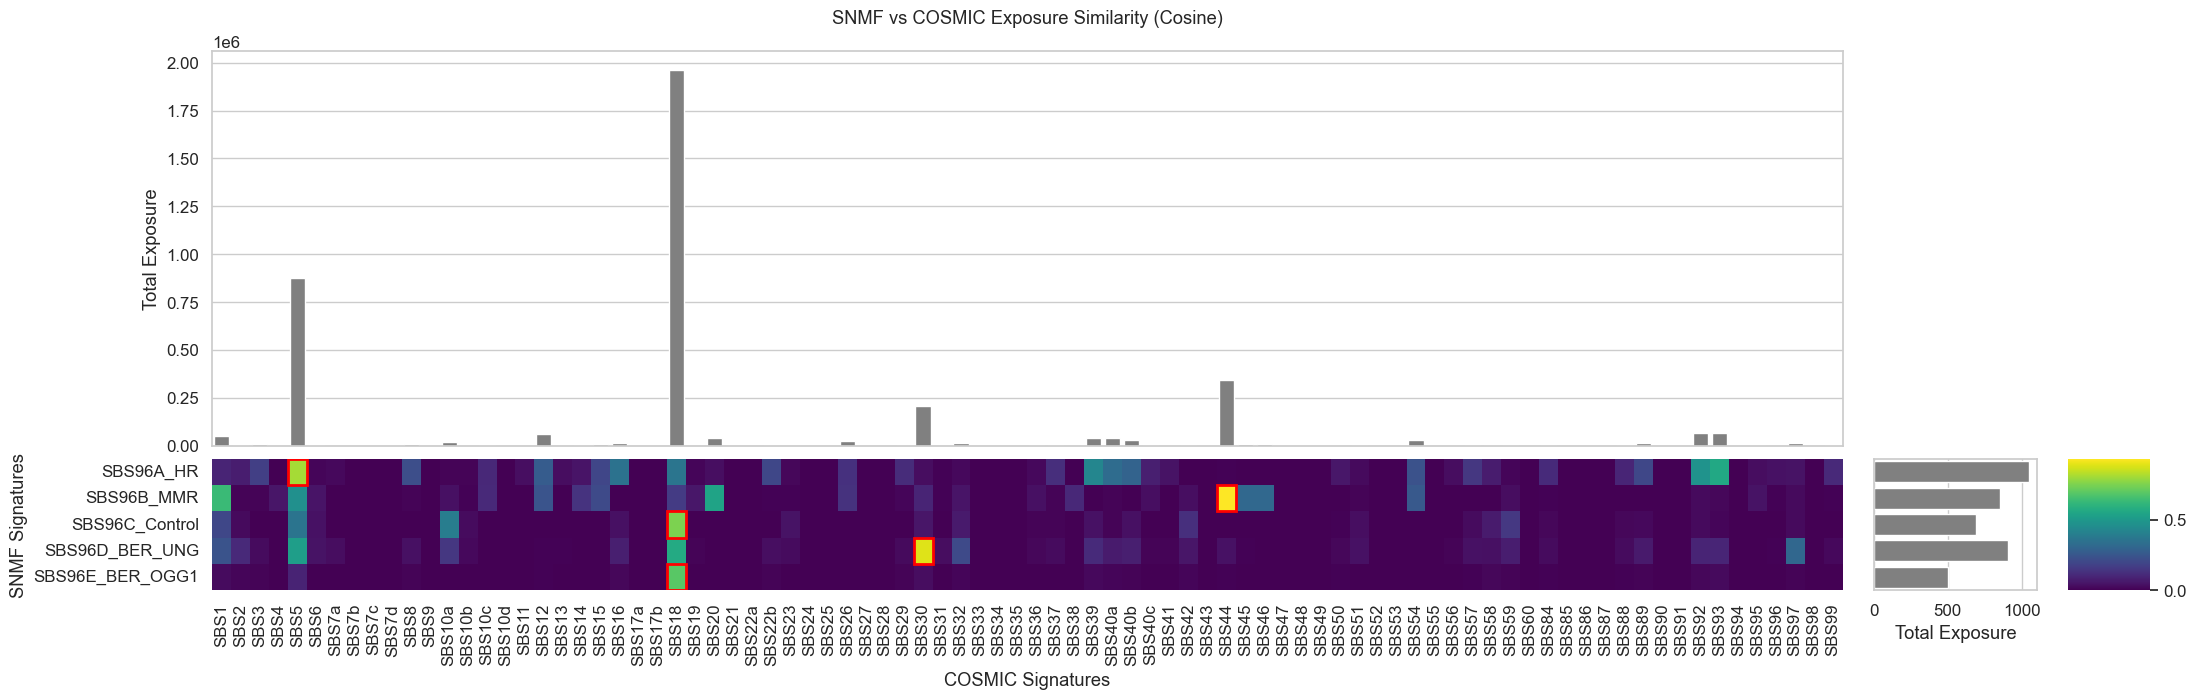


Highest 20 COSMIC signatures by total exposure:
SBS18     1961653
SBS5       874297
SBS44      345205
SBS30      206328
SBS93       67776
SBS92       65636
SBS12       58784
SBS1        52284
SBS39       42499
SBS20       38493
SBS40a      37474
SBS40b      29537
SBS54       29150
SBS26       22015
SBS10a      18297
SBS32       13880
SBS16       13505
SBS89       11696
SBS97       11663
SBS8        10868
dtype: int64


In [79]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.gridspec as gridspec

# --- Load COSMIC exposures ---
bootstrap = "multinomial"
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
exposure_dir = os.path.join(project_root, "data", "processed","zou2021","splits_new", "split_10", f"cosmic_fit_{bootstrap}")
cosmic_path = os.path.join(exposure_dir, "test", "Assignment_Solution", "Activities", "Assignment_Solution_Activities.txt")
cosmic_exposures = pd.read_csv(cosmic_path, sep="\t", index_col=0)
cosmic_exposures.index = ['-'.join(s.split('-')[:3]) for s in cosmic_exposures.index]

# --- Load SNMF exposures ---
model_path = os.path.join(project_root, "results", "analysis", "bootstrap_comparison_new", "SNMF_results_multinomial_lc01", "split_10")
exposures_path = os.path.join(model_path, "Exposures_test.txt")
snmf_exposures = pd.read_csv(exposures_path, sep="\t", index_col=0)
snmf_exposures.index = ['-'.join(s.split('-')[:3]) for s in snmf_exposures.index]
snmf_exposures.columns = renamed_columns

# --- Align ---
common_idx = cosmic_exposures.index.intersection(snmf_exposures.index)
cosmic_exposures = cosmic_exposures.loc[common_idx]
snmf_exposures = snmf_exposures.loc[common_idx]

# --- Cosine similarity ---
similarity = pd.DataFrame(
    cosine_similarity(snmf_exposures.T, cosmic_exposures.T),
    index=snmf_exposures.columns,
    columns=cosmic_exposures.columns
)

# --- Marginal sums ---
cosmic_sums = cosmic_exposures.sum(axis=0)   # per COSMIC signature
snmf_sums = snmf_exposures.sum(axis=0)       # per SNMF signature

# --- Plot with barplots + heatmap ---
fig = plt.figure(figsize=(25, 7))
gs = gridspec.GridSpec(
    2, 3, width_ratios=[20, 2, 1], height_ratios=[15, 5], 
    wspace=0.05, hspace=0.05
)

# --- Top barplot (COSMIC sums) ---
ax_top = plt.subplot(gs[0, 0])
ax_top.bar(cosmic_sums.index, cosmic_sums.values, color="gray")
ax_top.set_xlim(-0.5, len(cosmic_sums) - 0.5)
ax_top.set_xticks([])
ax_top.set_ylabel("Total Exposure")
ax_top.tick_params(axis="x", bottom=False)
ax_top.set_title("SNMF vs COSMIC Exposure Similarity (Cosine)", pad=20)

# --- Right barplot (SNMF sums) ---
ax_right = plt.subplot(gs[1, 1])
ax_right.barh(range(len(snmf_sums)), snmf_sums.values, color="gray")
ax_right.set_ylim(len(snmf_sums) - 0.5, -0.5)  # flip axis to match heatmap order
ax_right.set_yticks([])
ax_right.set_xlabel("Total Exposure")

# --- Heatmap ---
ax_heatmap = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 2])  # colorbar on far right
sns.heatmap(
    similarity, cmap="viridis", annot=False, 
    cbar=True, cbar_ax=cbar_ax, ax=ax_heatmap
)

# --- Add red squares for max similarity per SNMF signature ---
for i, row in enumerate(similarity.index):
    j = similarity.loc[row].idxmax()
    col_idx = similarity.columns.get_loc(j)
    rect = plt.Rectangle(
        (col_idx, i), 1, 1, fill=False, edgecolor="red", lw=2
    )
    ax_heatmap.add_patch(rect)

ax_heatmap.set_ylabel("SNMF Signatures")
ax_heatmap.set_xlabel("COSMIC Signatures")
ax_heatmap.tick_params(axis="x", rotation=90)

plt.tight_layout()

# --- Save figure (supplementary TCGA folder) ---
fig_dir = os.path.join(project_root, "results", "figures", "sup", "tcga")
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, "snmf_vs_cosmic_similarity_heatmap.pdf")
plt.savefig(fig_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved supplementary figure to {fig_path}")

plt.show()

# --- Largest 20 cosmic signatures ---
print("\nHighest 20 COSMIC signatures by total exposure:")
print(cosmic_sums.sort_values(ascending=False).head(20))


Saved annotated COSMIC exposures to:
/Users/sande/Projects/SNMF/data/processed/zou2021/splits_new/split_10/cosmic_fit_multinomial/Avg_Cosmic_Signature_Exposure_Annotated.txt
Saved supplementary figure to /Users/sande/Projects/SNMF/results/figures/sup/tcga/avg_cosmic_signature_exposure_per_geneKO.pdf


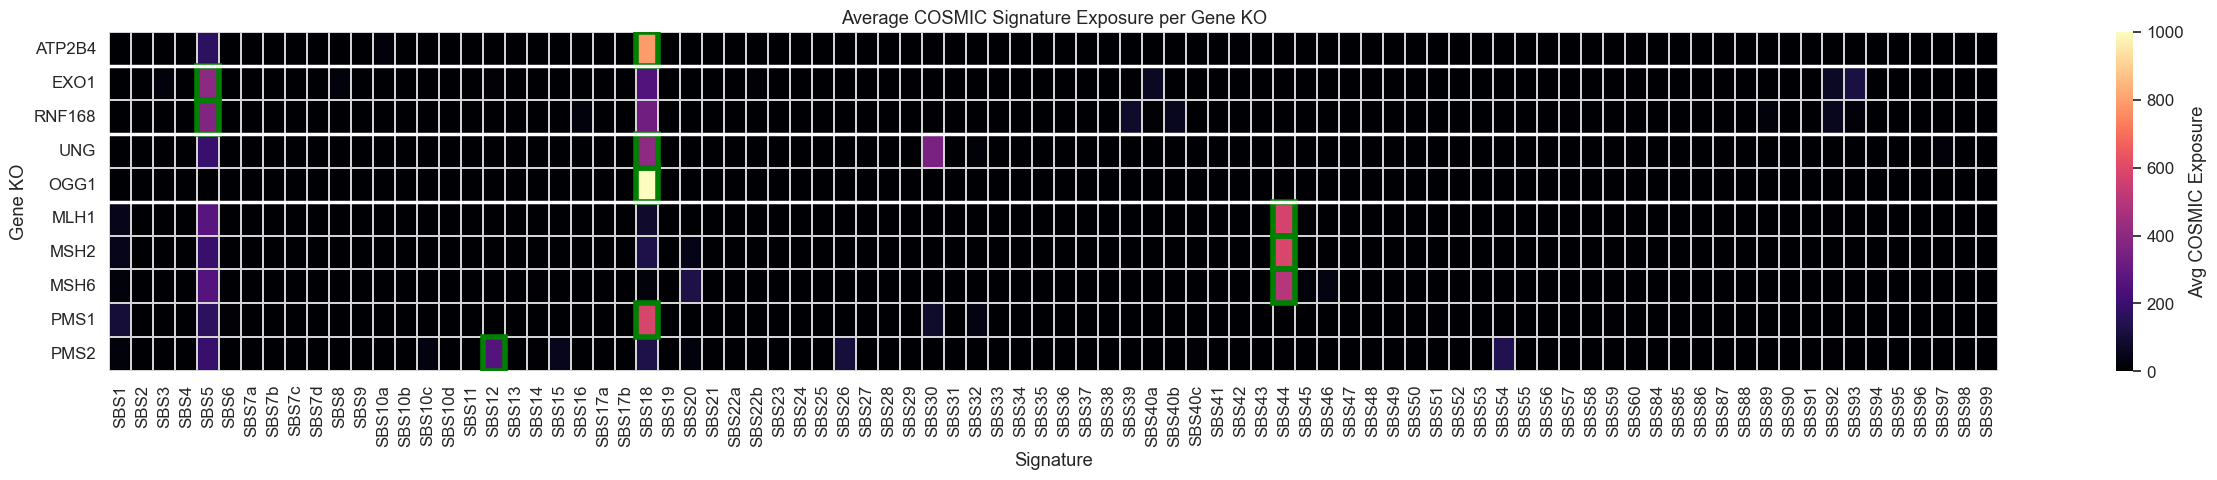

In [80]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Load COSMIC exposures ---
bootstrap = "multinomial"
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
exposure_dir = os.path.join(project_root, "data", "processed","zou2021","splits_new", "split_10", f"cosmic_fit_{bootstrap}")
cosmic_path = os.path.join(exposure_dir, "test", "Assignment_Solution", "Activities", "Assignment_Solution_Activities.txt")
cosmic_exposures = pd.read_csv(cosmic_path, sep="\t", index_col=0)
cosmic_exposures.index = ['-'.join(s.split('-')[:3]) for s in cosmic_exposures.index]

# --- Extract gene_KO from cell IDs ---
cosmic_exposures["gene_KO"] = [idx.split("_")[0] for idx in cosmic_exposures.index]

# --- Average exposures per gene KO ---
avg_cosmic_per_gene = cosmic_exposures.groupby("gene_KO").mean()
avg_cosmic_per_gene = avg_cosmic_per_gene.drop(columns=["gene_KO"], errors="ignore")

# --- Transpose to signatures x genes ---
cosmic_signature_exposures = avg_cosmic_per_gene.T

# --- Map genes to pathways ---
gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathway_genes.items()
    for gene in genes
}

# --- Average per pathway ---
cosmic_pathway_exposures = {
    pathway: cosmic_signature_exposures[[g for g in genes if g in cosmic_signature_exposures.columns]].mean(axis=1)
    for pathway, genes in pathway_genes.items()
}
cosmic_pathway_df = pd.DataFrame(cosmic_pathway_exposures)

# --- Dominant pathway per signature ---
cosmic_dominant_pathway = cosmic_pathway_df.idxmax(axis=1)
cosmic_pathway_counts = cosmic_dominant_pathway.value_counts()

# --- Top gene in dominant pathway ---
cosmic_top_gene_in_pathway = []
for sig in cosmic_signature_exposures.index:
    pathway = cosmic_dominant_pathway.get(sig, "Unknown")
    genes = pathway_genes.get(pathway, [])
    available_genes = [g for g in genes if g in cosmic_signature_exposures.columns]
    if available_genes:
        top_gene = cosmic_signature_exposures.loc[sig, available_genes].idxmax()
    else:
        top_gene = "Unknown"
    cosmic_top_gene_in_pathway.append(top_gene)

# --- Reorder genes by pathway ---
ordered_genes = [gene for genes in pathway_genes.values() for gene in genes]
avg_cosmic_per_gene = avg_cosmic_per_gene.loc[ordered_genes]

# --- Save annotated cosmic exposures ---
cosmic_annotated_output_path = os.path.join(exposure_dir, "Avg_Cosmic_Signature_Exposure_Annotated.txt")
avg_cosmic_per_gene.to_csv(cosmic_annotated_output_path, sep="\t")
print(f"Saved annotated COSMIC exposures to:\n{cosmic_annotated_output_path}")

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(25, 5))
sns.heatmap(
    avg_cosmic_per_gene,
    cmap="magma",
    linewidths=0.01, linecolor="lightgray",
    annot=False,
    cbar_kws={"label": "Avg COSMIC Exposure"},
    ax=ax
)
plt.title("Average COSMIC Signature Exposure per Gene KO")
plt.xlabel("Signature")
plt.ylabel("Gene KO")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# --- Add separators between pathways ---
separators = np.cumsum([len(v) for v in pathway_genes.values()])[:-1]
for sep in separators:
    ax.axhline(sep, color="white", linewidth=2.5)

# --- Add green boxes around max per row ---
for i, row in enumerate(avg_cosmic_per_gene.index):
    j = avg_cosmic_per_gene.loc[row].idxmax()
    col_idx = avg_cosmic_per_gene.columns.get_loc(j)
    rect = plt.Rectangle(
        (col_idx, i), 1, 1, fill=False, edgecolor="green", lw=4
    )
    ax.add_patch(rect)

plt.tight_layout()

# --- Save figure ---
fig_dir = os.path.join(project_root, "results", "figures", "sup", "tcga")
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, "avg_cosmic_signature_exposure_per_geneKO.pdf")
plt.savefig(fig_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved supplementary figure to {fig_path}")

plt.show()
